# Views Over Time Analysis

This notebook analyzes how audience attention changed over time for the three creators in my scaled extreme eating dataset: ErikTheElectric, Matt Stonie, and Nikocado Avocado.

The goal is to visualize whether views increased over time and whether each creator shows different engagement patterns.

In [3]:
import sys
!{sys.executable} -m pip install matplotlib



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("scaled_extreme_eating_dataset.csv")

df.head()

df["upload_date"] = pd.to_datetime(df["upload_date"], errors="coerce")
df["views"] = pd.to_numeric(df["views"], errors="coerce")

df = df.dropna(subset=["upload_date", "views"])

df["year"] = df["upload_date"].dt.year

df[["creator", "video_title", "upload_date", "year", "views"]].head()

,creator,video_title,upload_date,year,views
0,ErikTheElectric,I Let AI Control Every Meal for Two Weeks,2026-01-17,2026,4663395
1,ErikTheElectric,I Survived The World's Heaviest People's Diets...,2025-08-09,2025,12597224
2,ErikTheElectric,I Ate The Biggest Foods on the Internet for 10...,2025-02-25,2025,9759599
3,ErikTheElectric,I Let Popular Food Companies Control My Diet F...,2024-10-07,2024,13353904
4,ErikTheElectric,I Finished The ENTIRE Menu Everywhere My Tesla...,2024-06-09,2024,15658181


## Average Views Over Time by Creator

The following graphs show the average number of views per year for each creator. I use yearly averages rather than individual video views because the dataset includes many videos with large differences in popularity.

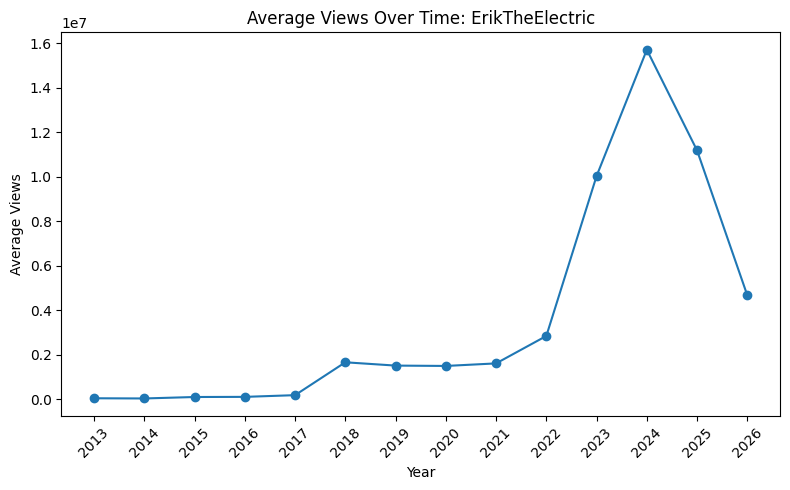

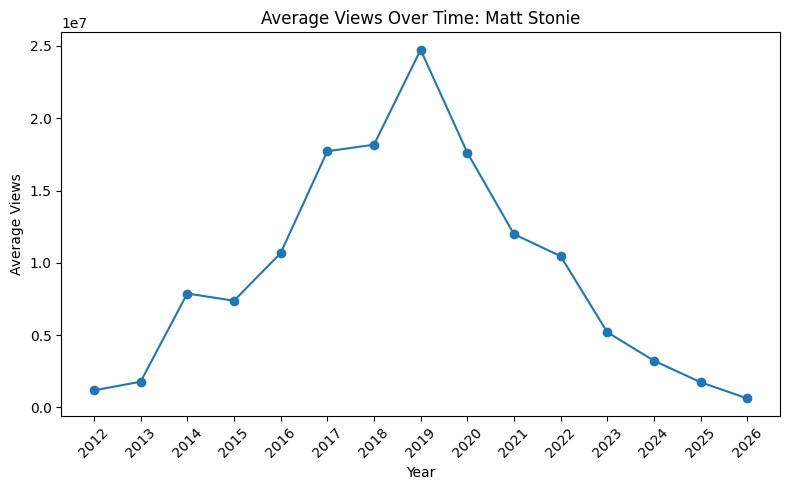

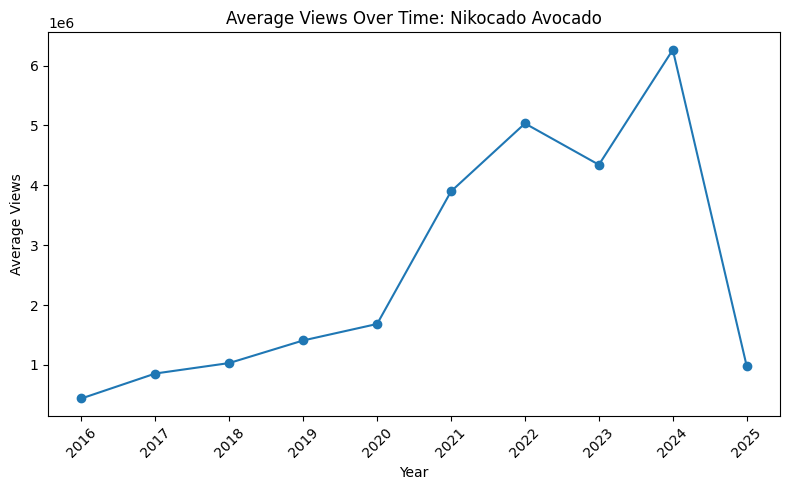

In [3]:
creators = ["ErikTheElectric", "Matt Stonie", "Nikocado Avocado"]

for creator in creators:
    creator_df = df[df["creator"] == creator]

    yearly_views = (
        creator_df.groupby("year")["views"]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    plt.figure(figsize=(8, 5))
    plt.plot(yearly_views["year"], yearly_views["views"], marker="o")
    plt.title(f"Average Views Over Time: {creator}")
    plt.xlabel("Year")
    plt.ylabel("Average Views")
    plt.xticks(yearly_views["year"], rotation=45)
    plt.tight_layout()

    filename = f"{creator.lower().replace(' ', '_')}_views_over_time.png"
    plt.savefig(filename, dpi=300)

    plt.show()

## Interpretation

The graphs generated from the scaled dataset revealed that engagement patterns differed significantly across creators. ErikTheElectric experienced dramatic view growth after 2022, particularly during videos centered on narrative-based spectacle such as AI-controlled diets and multi-day food challenges. 

Nikocado Avocado also showed substantial growth over time, though his engagement fluctuated more heavily. 

In contrast, Matt Stonie’s average views peaked around 2018–2019 before gradually declining in later years.

These differences suggest that platform attention does not reward all forms of excess equally. Earlier competitive-eating formats centered primarily on quantity and speed may have become less novel over time, while narrative-driven and emotionally exaggerated formats appear to align more closely with newer platform incentives and audience expectations.